In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import inspect

sp.init_printing("mathjax")

# Solving for angular acceleration

In [2]:
r_inner, rcm, m, I, g, t = sp.symbols("r_\\text{inner} r_\\text{cm} m I g t")
muv, muq, muc = sp.symbols("\\mu_v \\mu_q \\mu_c")

theta = sp.Function("\\theta")(t)
theta_d = sp.diff(theta, t)

In [3]:
T = sp.Rational(1, 2) * I * theta_d**2
V = -m*g*rcm*sp.cos(theta)
L = T - V

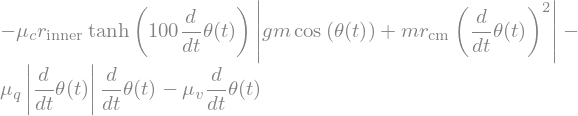

In [4]:
normal_force = sp.Abs(-m*rcm*theta_d*theta_d - m*g*sp.cos(theta))
friction_forces = -muv*theta_d - muq*sp.Abs(theta_d)*theta_d - muc*normal_force*r_inner*sp.tanh(theta_d * 100)

friction_forces

In [5]:
eq_motion = sp.Equality(
    sp.diff(
        sp.diff(L, theta_d),
        t
    )
    -
    sp.diff(L, theta),
    friction_forces
)

acc = sp.solve(eq_motion, sp.diff(theta_d, t))[0]
acc_func = sp.lambdify((I, rcm, m, g, theta, theta_d, r_inner, muv, muq, muc), acc)

inspect.getsource(acc_func)

'def _lambdifygenerated(I, Dummy_67, m, g, _Dummy_65, _Dummy_64, Dummy_66, Dummy_68, Dummy_69, Dummy_70):\n    return -(_Dummy_64*Dummy_68 + _Dummy_64*Dummy_69*abs(_Dummy_64) + Dummy_66*Dummy_70*tanh(100*_Dummy_64)*abs(m*(_Dummy_64**2*Dummy_67 + g*cos(_Dummy_65))) + Dummy_67*g*m*sin(_Dummy_65))/I\n'

# RK4 Simulation

In [6]:
rcm_sim = 10e-2
g_sim = 9.81
I_sim = 1/3 * (2*rcm_sim)**2
m_sim = 200e-3
r_inner_sim = 8e-3
muv_sim = 0.0001
muq_sim = 0
muc_sim = 0.1

y = np.array([2*np.pi/3, 0])

def f(y, t):
    return np.array([
        y[1],
        acc_func(I_sim, rcm_sim, m_sim, g_sim, y[0], y[1], r_inner_sim, muv_sim, muq_sim, muc_sim)
    ])

h = 4.687e-3
t = 0
sim_time = 120

I_sim

In [7]:
past_positions = np.array([])
first = True

for i in range(int(sim_time/h)):
    k1 = h*f(y, t)
    k2 = h*f(y + k1/2, t + h/2)
    k3 = h*f(y + k2/2, t + h/2)
    k4 = h*f(y + k3, t + h)

    y = y + k1/6 + k2/3 + k3/3 + k4/6

    if (first):
        past_positions = np.array([y])
        first = False
    else:
        past_positions = np.vstack([past_positions, y])


Getting the position of the end of the arm. Note: I'm now assuming the arm is a solid bar.

In [8]:
# getting the simulated angles out
theta_sim = past_positions[:, 0]

# simulating the position measurements we would get, including uncertainties
standard_error = 0.003
x_sim_err = np.random.normal(0, standard_error, len(theta_sim))
y_sim_err = np.random.normal(0, standard_error, len(theta_sim))

x_sim = 2*rcm_sim*np.sin(theta_sim) + x_sim_err
y_sim = -2*rcm_sim*np.cos(theta_sim) + y_sim_err

theta_sim2 = np.arctan2(x_sim, -y_sim)
theta_sim2_err = np.hypot(
    standard_error * 1/((1 + (x_sim / y_sim)**2) * y_sim),
    standard_error * x_sim/((1 + (x_sim / y_sim)**2) * y_sim**2),
)

print("initial condition recorded: " + str(past_positions[0, :]))

initial condition recorded: [ 2.09425556 -0.05950072]


In [9]:
# fig, ax = plt.subplots()
# ax.set_aspect('equal')
# ax.set_xlim(-2.2*2*rcm_sim, 2.2*2*rcm_sim)
# ax.set_ylim(-2.2*2*rcm_sim, 2.2*2*rcm_sim)

# line, = ax.plot([], [], "o-", lw=1)

# def init():
#     line.set_data([], [])
#     return line,

# def update(i):
#     this_x = [0, x_sim[i]]
#     this_y = [0, y_sim[i]]

#     line.set_data(this_x, this_y)
#     return line,

# ani = FuncAnimation(fig, update, frames=len(x_sim), init_func=init, blit=True, interval=data_rate)

# ani.save("test_single.mp4")

In [10]:
data = np.vstack(
    (
        np.arange(0, sim_time, h)[:-1],
        x_sim,
        y_sim,
        np.full(len(x_sim), standard_error),
        np.full(len(y_sim), standard_error),
        np.full(len(x_sim), np.nan), #would be the second arm, but this is a single pendulum
        np.full(len(y_sim), np.nan),
        np.full(len(y_sim), np.nan),
        np.full(len(y_sim), np.nan),
        theta_sim2,
        np.full(len(y_sim), np.nan),
        theta_sim2_err,
        np.full(len(y_sim), np.nan),
    )
).transpose()

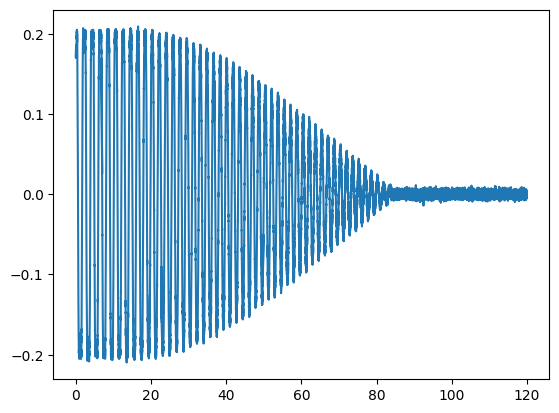

In [11]:
plt.plot(data[:, 0], data[:, 1])
# plt.xlim(0, 5)

In [12]:
np.savetxt("sim_data.csv", data, delimiter=",", fmt="%f", header="time (s), x1 (pixels), y1 (pixels), x1 error (pixels), y1 error (pixels), x2 (pixels), y2 (pixels), x2 error (pixels), y2 error (pixels), angle1 (the smaller arm) (rad), angle2 (the larger arm) (rad), angle1 error (rad), angle2 error (rad)")

In [13]:
data

array([[ 0.00000000e+00,  1.70790176e-01,  9.27034044e-02, ...,
                    nan,  1.54378505e-02,             nan],
       [ 4.68700000e-03,  1.74059438e-01,  1.03797759e-01, ...,
                    nan,  1.48031929e-02,             nan],
       [ 9.37400000e-03,  1.79106420e-01,  1.01746477e-01, ...,
                    nan,  1.45638867e-02,             nan],
       ...,
       [ 1.19982513e+02,  1.18735883e-03, -1.98356338e-01, ...,
                    nan,  1.51240252e-02,             nan],
       [ 1.19987200e+02, -1.08839491e-03, -2.04266690e-01, ...,
                    nan,  1.46864739e-02,             nan],
       [ 1.19991887e+02,  9.74828476e-04, -2.01924801e-01, ...,
                    nan,  1.48568428e-02,             nan]])